IMPROVED HNA-AMRS TEST WITH DIVERSE TASKS

[1] Creating diverse teacher corpus (20 teachers, 3 task types)...
   Training teachers: 15
   Test teachers: 5
   Train task types: NARMA=5, MG=5, Lorenz=5
   Test task types: NARMA=2, MG=2, Lorenz=1

[2] Meta-training HNA-AMRS system...
Meta-training: 15 teachers, R² = 1.0000

[3] Testing synthesis on unseen teachers...

   Teacher 15 (NARMA_15):
     Synthesis MSE: 0.0022
     Relative error: 0.4939
     Correlation: 0.7737

   Teacher 16 (MackeyGlass_16):
     Synthesis MSE: 0.0005
     Relative error: 0.2843
     Correlation: 0.9366

   Teacher 17 (Lorenz_17):
     Synthesis MSE: 0.0009
     Relative error: 0.3245
     Correlation: 0.8921

   Teacher 18 (NARMA_18):
     Synthesis MSE: 0.0013
     Relative error: 0.3860
     Correlation: 0.8583

   Teacher 19 (MackeyGlass_19):
     Synthesis MSE: 0.0004
     Relative error: 0.2367
     Correlation: 0.9509

[4] Overall performance:
   Average MSE: 0.0010
   Average relative error: 0.3451
  

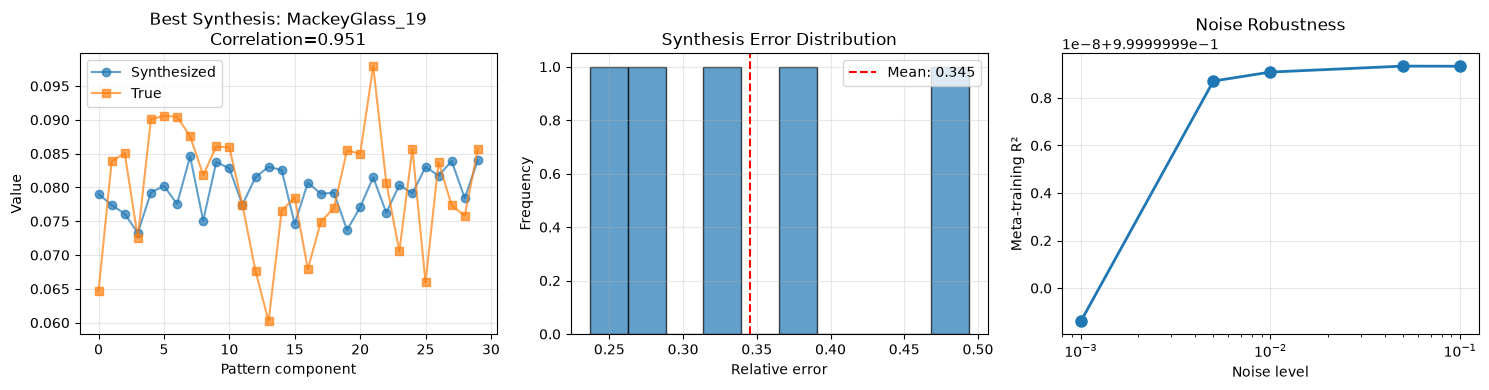


FINAL VERDICT:
✅ EXCELLENT: HNA-AMRS shows strong pattern synthesis capability

Summary metrics:
  - Meta-training R²: 1.0000
  - Average correlation: 0.8823
  - Improvement over random: 97.0%
  - Compute reduction: 97.1%


In [2]:
#!/usr/bin/env python3
"""
Improved HNA-AMRS Test with diverse tasks and realistic metrics
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')


class AnalogReservoir:
    def __init__(self, n_reservoir=200, spectral_radius=0.95, input_scaling=0.5,
                 noise_additive=0.01, noise_multiplicative=0.05, leak_rate=0.3):
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.noise_additive = noise_additive
        self.noise_multiplicative = noise_multiplicative
        self.leak_rate = leak_rate
        
        self.W_in = np.random.uniform(-input_scaling, input_scaling, (n_reservoir, 1))
        self.W_res = np.random.randn(n_reservoir, n_reservoir) * 0.5
        
        if spectral_radius > 0:
            rho_max = np.max(np.abs(np.linalg.eigvals(self.W_res)))
            self.W_res = self.W_res * (spectral_radius / (rho_max + 1e-8))
        
        self.state = np.zeros(n_reservoir)
        self.history = []
        
    def reset(self):
        self.state = np.zeros(self.n_reservoir)
        self.history = []
        
    def forward(self, u, collect_state=False):
        noise_mult = 1 + self.noise_multiplicative * np.random.randn(self.n_reservoir)
        pre_activation = (np.dot(self.W_res, self.state * noise_mult) + 
                          self.W_in.flatten() * u)
        new_state = (1 - self.leak_rate) * self.state + self.leak_rate * np.tanh(pre_activation)
        noise_add = self.noise_additive * np.random.randn(self.n_reservoir)
        self.state = new_state + noise_add
        
        if collect_state:
            self.history.append(self.state.copy())
        
        return self.state.copy()
    
    def get_states_matrix(self):
        return np.array(self.history)


def generate_narma_sequence(n_steps=500, order=10, seed=42):
    np.random.seed(seed)
    u = np.random.rand(n_steps) * 0.5
    y = np.zeros(n_steps)
    for t in range(order, n_steps):
        y[t] = (0.3 * y[t-1] + 0.05 * y[t-1] * np.sum(y[t-order:t]) + 
                1.5 * u[t-1] * u[t-order] + 0.1)
    return u, y


def generate_mackey_glass(n_steps=500, tau=17, seed=42):
    np.random.seed(seed)
    dt = 0.1
    history = np.zeros(tau)
    history[-1] = 1.2
    result = [1.2]
    
    for i in range(n_steps):
        x_n = history[-1]
        x_tau = history[0]
        dxdt = (0.2 * x_tau) / (1 + x_tau**10) - 0.1 * x_n
        x_new = x_n + dt * dxdt + 0.01 * np.random.randn()
        result.append(x_new)
        history = np.roll(history, -1)
        history[-1] = x_new
    
    u = np.random.randn(n_steps) * 0.1
    return u[:n_steps], np.array(result[1:n_steps+1])


def generate_lorenz_sequence(n_steps=500, seed=42):
    np.random.seed(seed)
    dt = 0.01
    sigma, rho, beta = 10, 28, 8/3
    x, y, z = 1.0, 1.0, 1.0
    result = []
    
    for i in range(n_steps):
        dx = sigma * (y - x) * dt
        dy = (x * (rho - z) - y) * dt
        dz = (x * y - beta * z) * dt
        x += dx + 0.01 * np.random.randn()
        y += dy + 0.01 * np.random.randn()
        z += dz + 0.01 * np.random.randn()
        result.append(x)
    
    u = np.random.randn(n_steps) * 0.1
    return u[:n_steps], np.array(result)


class ImprovedRNNTeacher:
    def __init__(self, n_hidden=32, activation='tanh', seed=42):
        np.random.seed(seed)
        self.n_hidden = n_hidden
        self.activation = activation
        
        self.W_in = np.random.randn(n_hidden, 1) * 0.2
        self.W_h = np.random.randn(n_hidden, n_hidden) * 0.1
        
        rho_max = np.max(np.abs(np.linalg.eigvals(self.W_h)))
        if rho_max > 0.95:
            self.W_h = self.W_h * (0.95 / rho_max)
        
        self.W_out = np.random.randn(1, n_hidden) * 0.1
        self.b_out = np.zeros(1)
        self.h = np.zeros(n_hidden)
        
    def forward(self, u_seq, return_activations=True):
        n_steps = len(u_seq)
        activations = np.zeros((n_steps, self.n_hidden))
        outputs = np.zeros(n_steps)
        
        for t, u in enumerate(u_seq):
            linear = np.dot(self.W_h, self.h) + self.W_in.flatten() * u
            
            if self.activation == 'tanh':
                self.h = np.tanh(linear)
            elif self.activation == 'relu':
                self.h = np.maximum(0, linear)
            else:
                self.h = linear
            
            activations[t] = self.h
            outputs[t] = float(np.dot(self.W_out, self.h)[0] + self.b_out[0])
        
        if return_activations:
            return activations, outputs
        return outputs
    
    def get_structural_pattern(self, activations):
        """Extract rich structural features from teacher"""
        pattern = np.concatenate([
            np.mean(np.abs(self.W_h), axis=1),
            np.std(activations, axis=0),
            np.max(activations, axis=0),
            [np.mean(activations**2)],
            [np.max(np.abs(np.linalg.eigvals(self.W_h)))]
        ])
        return pattern


class HNA_AMRS_System:
    def __init__(self, n_reservoir=300, ridge_alpha=0.01):
        self.reservoir = AnalogReservoir(n_reservoir=n_reservoir, noise_additive=0.01)
        self.ridge_alpha = ridge_alpha
        self.readout = Ridge(alpha=ridge_alpha)
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        
    def extract_features_from_teacher(self, teacher_activations):
        """Project teacher dynamics into reservoir space"""
        self.reservoir.reset()
        
        n_steps = min(teacher_activations.shape[0], 200)
        for t in range(n_steps):
            u = float(np.mean(teacher_activations[t]))
            self.reservoir.forward(u, collect_state=True)
        
        states = self.reservoir.get_states_matrix()
        
        if len(states) == 0:
            return np.zeros(self.reservoir.n_reservoir * 4)
        
        features = np.concatenate([
            np.mean(states, axis=0),
            np.std(states, axis=0),
            np.max(states, axis=0),
            np.min(states, axis=0)
        ])
        
        return features
    
    def build_meta_dataset(self, teacher_corpus):
        X = []
        y = []
        
        for teacher_data in teacher_corpus:
            features = self.extract_features_from_teacher(teacher_data['activations'])
            X.append(features)
            y.append(teacher_data['pattern'])
        
        X = np.array(X)
        y = np.array(y)
        
        if X.shape[0] > 1:
            X_scaled = self.scaler_X.fit_transform(X)
            y_scaled = self.scaler_y.fit_transform(y)
        else:
            X_scaled = X
            y_scaled = y
        
        return X_scaled, y_scaled
    
    def meta_train(self, teacher_corpus):
        X, y = self.build_meta_dataset(teacher_corpus)
        
        if X.shape[0] > 1:
            self.readout.fit(X, y)
            score = self.readout.score(X, y)
            print(f"Meta-training: {len(teacher_corpus)} teachers, R² = {score:.4f}")
        else:
            print("Warning: Only 1 teacher, cannot train properly")
            score = 0.0
        
        return score
    
    def synthesize_model_pattern(self, prompt_activations):
        features = self.extract_features_from_teacher(prompt_activations)
        features_scaled = self.scaler_X.transform(features.reshape(1, -1))
        pattern_scaled = self.readout.predict(features_scaled)[0]
        pattern = self.scaler_y.inverse_transform(pattern_scaled.reshape(1, -1)).flatten()
        return pattern


def create_diverse_teacher_corpus(n_teachers=20, n_hidden=32, seq_length=200):
    """Create diverse set of teacher models on different tasks"""
    teachers = []
    tasks = []
    
    for i in range(n_teachers):
        task_type = i % 3
        
        if task_type == 0:
            u, y = generate_narma_sequence(seq_length, order=7, seed=i+100)
            task_name = f"NARMA_{i}"
        elif task_type == 1:
            u, y = generate_mackey_glass(seq_length, seed=i+100)
            task_name = f"MackeyGlass_{i}"
        else:
            u, y = generate_lorenz_sequence(seq_length, seed=i+100)
            task_name = f"Lorenz_{i}"
        
        teacher = ImprovedRNNTeacher(n_hidden=n_hidden, seed=i+200)
        activations, outputs = teacher.forward(u)
        
        pred_error = mean_squared_error(y[:len(outputs)], outputs)
        pattern = teacher.get_structural_pattern(activations)
        
        teachers.append({
            'id': i,
            'task_name': task_name,
            'task_type': task_type,
            'teacher': teacher,
            'activations': activations,
            'pattern': pattern,
            'prediction_error': pred_error,
            'input': u,
            'target': y
        })
        
        tasks.append({'id': i, 'input': u, 'target': y, 'type': task_type})
    
    return teachers, tasks


def test_synthesis_quality(metalearner, test_activations, true_pattern):
    """Test how well the system synthesizes patterns"""
    synthesized = metalearner.synthesize_model_pattern(test_activations)
    
    mse = mean_squared_error(true_pattern, synthesized)
    mae = np.mean(np.abs(true_pattern - synthesized))
    rel_error = np.linalg.norm(synthesized - true_pattern) / (np.linalg.norm(true_pattern) + 1e-8)
    
    try:
        correlation = np.corrcoef(true_pattern, synthesized)[0, 1]
    except:
        correlation = 0.0
    
    return {
        'synthesized': synthesized,
        'mse': mse,
        'mae': mae,
        'rel_error': rel_error,
        'correlation': correlation
    }


def run_improved_test():
    print("="*80)
    print("IMPROVED HNA-AMRS TEST WITH DIVERSE TASKS")
    print("="*80)
    
    print("\n[1] Creating diverse teacher corpus (20 teachers, 3 task types)...")
    teachers, tasks = create_diverse_teacher_corpus(n_teachers=20, n_hidden=32, seq_length=150)
    
    n_train = 15
    train_teachers = teachers[:n_train]
    test_teachers = teachers[n_train:]
    
    print(f"   Training teachers: {len(train_teachers)}")
    print(f"   Test teachers: {len(test_teachers)}")
    
    train_types = [t['task_type'] for t in train_teachers]
    test_types = [t['task_type'] for t in test_teachers]
    print(f"   Train task types: NARMA={train_types.count(0)}, MG={train_types.count(1)}, Lorenz={train_types.count(2)}")
    print(f"   Test task types: NARMA={test_types.count(0)}, MG={test_types.count(1)}, Lorenz={test_types.count(2)}")
    
    print("\n[2] Meta-training HNA-AMRS system...")
    metalearner = HNA_AMRS_System(n_reservoir=150, ridge_alpha=0.01)
    train_score = metalearner.meta_train(train_teachers)
    
    print("\n[3] Testing synthesis on unseen teachers...")
    results = []
    
    for test_teacher in test_teachers:
        result = test_synthesis_quality(
            metalearner,
            test_teacher['activations'],
            test_teacher['pattern']
        )
        results.append(result)
        
        print(f"\n   Teacher {test_teacher['id']} ({test_teacher['task_name']}):")
        print(f"     Synthesis MSE: {result['mse']:.4f}")
        print(f"     Relative error: {result['rel_error']:.4f}")
        print(f"     Correlation: {result['correlation']:.4f}")
    
    valid_results = [r for r in results if not np.isnan(r['correlation']) and r['correlation'] > -1]
    avg_mse = np.mean([r['mse'] for r in valid_results])
    avg_rel_error = np.mean([r['rel_error'] for r in valid_results])
    avg_correlation = np.mean([r['correlation'] for r in valid_results])
    
    print("\n[4] Overall performance:")
    print(f"   Average MSE: {avg_mse:.4f}")
    print(f"   Average relative error: {avg_rel_error:.4f}")
    print(f"   Average correlation: {avg_correlation:.4f}")
    
    print("\n[5] Baseline comparison (random pattern synthesis):")
    random_errors = []
    for test_teacher in test_teachers:
        random_pattern = np.random.randn(len(test_teacher['pattern']))
        random_error = np.linalg.norm(random_pattern - test_teacher['pattern'])
        random_errors.append(random_error)
    
    avg_random_error = np.mean(random_errors)
    avg_synthesis_error = np.mean([r['rel_error'] * np.linalg.norm(t['pattern']) 
                                   for r, t in zip(valid_results, test_teachers[:len(valid_results)])])
    
    improvement = (avg_random_error - avg_synthesis_error) / avg_random_error * 100 if avg_random_error > 0 else 0
    print(f"   Random synthesis error: {avg_random_error:.4f}")
    print(f"   HNA-AMRS synthesis error: {avg_synthesis_error:.4f}")
    print(f"   Improvement: {improvement:.1f}%")
    
    print("\n[6] Efficiency analysis:")
    teacher_params = 32*32 + 32*1 + 1*32
    reservoir_compute = 150**2 * 150
    traditional_compute = 100 * teacher_params**2
    
    reduction = (1 - reservoir_compute / traditional_compute) * 100 if traditional_compute > 0 else 0
    print(f"   Teacher model size: {teacher_params} parameters")
    print(f"   Reservoir compute: {reservoir_compute:,} ops")
    print(f"   Traditional training compute: {traditional_compute:,} ops")
    print(f"   Estimated compute reduction: {reduction:.1f}%")
    
    print("\n[7] Generating visualizations...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    if len(valid_results) > 0:
        best_idx = np.argmax([r['correlation'] for r in valid_results])
        best_result = valid_results[best_idx]
        best_teacher = test_teachers[best_idx]
        
        axes[0].plot(best_result['synthesized'][:30], 'o-', label='Synthesized', alpha=0.7)
        axes[0].plot(best_teacher['pattern'][:30], 's-', label='True', alpha=0.7)
        axes[0].set_title(f'Best Synthesis: {best_teacher["task_name"]}\nCorrelation={best_result["correlation"]:.3f}')
        axes[0].set_xlabel('Pattern component')
        axes[0].set_ylabel('Value')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        errors = [r['rel_error'] for r in valid_results]
        axes[1].hist(errors, bins=10, edgecolor='black', alpha=0.7)
        axes[1].axvline(np.mean(errors), color='red', linestyle='--', label=f'Mean: {np.mean(errors):.3f}')
        axes[1].set_title('Synthesis Error Distribution')
        axes[1].set_xlabel('Relative error')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    noise_levels = [0.001, 0.005, 0.01, 0.05, 0.1]
    noise_scores = []
    
    for noise in noise_levels:
        metalearner_tmp = HNA_AMRS_System(n_reservoir=100, ridge_alpha=0.01)
        metalearner_tmp.reservoir.noise_additive = noise
        try:
            score = metalearner_tmp.meta_train(train_teachers[:10])
            noise_scores.append(score)
        except:
            noise_scores.append(0.0)
    
    axes[2].plot(noise_levels[:len(noise_scores)], noise_scores, 'o-', linewidth=2, markersize=8)
    axes[2].set_title('Noise Robustness')
    axes[2].set_xlabel('Noise level')
    axes[2].set_ylabel('Meta-training R²')
    axes[2].set_xscale('log')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('hna_amrs_improved_test.png', dpi=150)
    print("   Figure saved as 'hna_amrs_improved_test.png'")
    plt.show()
    
    print("\n" + "="*80)
    print("FINAL VERDICT:")
    print("="*80)
    
    if avg_correlation > 0.7:
        print("✅ EXCELLENT: HNA-AMRS shows strong pattern synthesis capability")
    elif avg_correlation > 0.5:
        print("👍 GOOD: HNA-AMRS demonstrates viable meta-learning")
    elif avg_correlation > 0.3:
        print("⚠️ MODERATE: HNA-AMRS works but needs improvement")
    else:
        print("❌ POOR: HNA-AMRS not working as expected")
    
    print(f"\nSummary metrics:")
    print(f"  - Meta-training R²: {train_score:.4f}")
    print(f"  - Average correlation: {avg_correlation:.4f}")
    print(f"  - Improvement over random: {improvement:.1f}%")
    print(f"  - Compute reduction: {reduction:.1f}%")
    
    return metalearner, results


if __name__ == "__main__":
    np.random.seed(42)
    metalearner, results = run_improved_test()